Clean Data set EDA

In [29]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


In [53]:
df=pd.read_excel(r'../data/processed/clean.xlsx')

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17808 entries, 0 to 17807
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Location             17808 non-null  str    
 1   Type                 17808 non-null  str    
 2   Price                17808 non-null  float64
 3   Area                 17808 non-null  str    
 4   Bedrooms             17808 non-null  int64  
 5   Bathrooms            17808 non-null  int64  
 6   Purpose              17808 non-null  str    
 7   Built Year           17808 non-null  int64  
 8   Kitchens             17808 non-null  int64  
 9   Store Rooms          17808 non-null  int64  
 10  Servant Quarters     17808 non-null  int64  
 11  Furnished            17808 non-null  int64  
 12  Gym                  17808 non-null  int64  
 13  Study Room           17808 non-null  int64  
 14  Drawing Room         17808 non-null  int64  
 15  Dining Room          17808 non-null  int64  
 1

In [55]:
df.head(5)

,Location,Type,Price,Area,Bedrooms,Bathrooms,Purpose,Built Year,Kitchens,Store Rooms,Servant Quarters,Furnished,Gym,Study Room,Drawing Room,Dining Room,Lawn/Garden,Swimming Pool,Electricity Backup,Lounge/Sitting Room
0,"DHA Phase 6 - Block F, DHA Phase 6, DHA Defenc...",House,81500000.0,1 Kanal,6,7,For Sale,2024,3,2,2,1,1,1,1,1,1,1,1,1
1,"Park View City, Lahore, Punjab",House,15000000.0,5 Marla,4,5,For Sale,2012,2,1,3,1,0,0,1,1,1,0,1,1
2,"Park View City - Rose Block, Park View City, L...",House,24000000.0,5 Marla,4,4,For Sale,2025,2,1,1,1,1,1,1,1,1,1,1,1
3,"DHA Phase 7 - Block S, DHA Phase 7, DHA Defenc...",House,75000000.0,1 Kanal,5,6,For Sale,2024,2,1,1,0,1,1,1,1,1,1,1,1
4,"DHA Phase 6, DHA Defence, Lahore, Punjab",House,69500000.0,1 Kanal,6,7,For Sale,2024,0,0,0,1,1,1,1,1,1,1,1,1


In [57]:
df.describe()

,Price,Bedrooms,Bathrooms,Built Year,Kitchens,Store Rooms,Servant Quarters,Furnished,Gym,Study Room,Drawing Room,Dining Room,Lawn/Garden,Swimming Pool,Electricity Backup,Lounge/Sitting Room
count,1.780800e+04,17808.000000,17808.000000,17808.000000,17808.000000,17808.000000,17808.000000,17808.000000,17808.000000,17808.000000,17808.000000,17808.000000,17808.000000,17808.000000,17808.000000,17808.000000
mean,5.823087e+07,4.410377,5.069744,2023.027403,1.684636,0.798911,0.860624,0.505559,0.526280,0.722428,0.879436,0.860175,0.679358,0.454627,0.832042,0.777235
std,7.851267e+07,1.208601,1.210699,4.281291,1.059390,0.784062,1.251900,0.499983,0.499323,0.447814,0.325629,0.346815,0.466737,0.497951,0.373840,0.416114
min,8.000000e+00,1.000000,1.000000,1960.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.100000e+07,3.000000,4.000000,2024.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
50%,3.600000e+07,5.000000,5.000000,2024.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
75%,7.100000e+07,5.000000,6.000000,2025.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,2.000000e+09,11.000000,8.000000,2121.000000,32.000000,22.000000,111.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Numerical columns

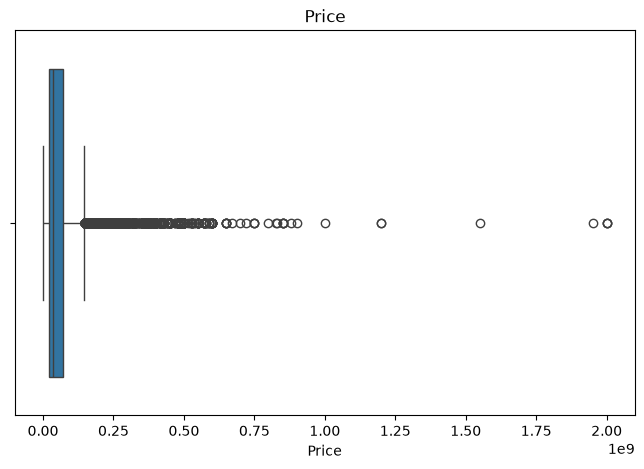

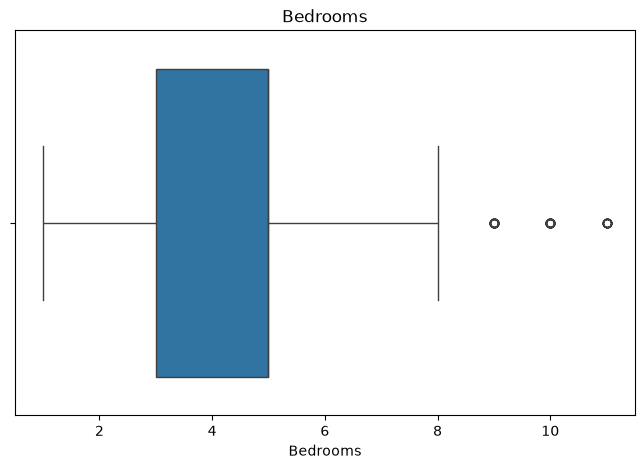

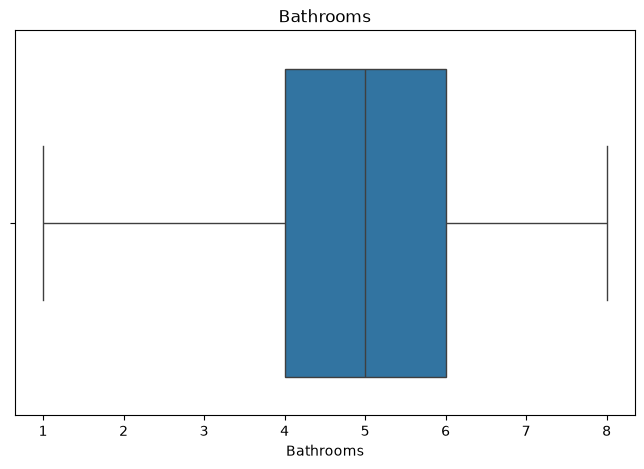

In [58]:
numerical_columns=[
    'Price',
    'Bedrooms',
    'Bathrooms'
]

for col in numerical_columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df[col])
    plt.title(col)
    

In [60]:
# Remove impossible price values (junk entries)
df = df[df["Price"] >= 100000] 

# Fix Built Year typos
df = df[(df["Built Year"] >= 1900) & (df["Built Year"] <= 2026)] 

# Sanity check bedrooms/bathrooms aren't 0
df = df[(df["Bedrooms"] > 0) & (df["Bathrooms"] > 0)] 

print("After cleaning:", df.shape)  

After cleaning: (17749, 20)


In [39]:
def convert_area_to_marla(area_str):
    area_str = str(area_str).strip().lower()
    try:
        if "kanal" in area_str:
            num = float(area_str.split("kanal")[0].strip())
            return num * 20  # 1 Kanal = 20 Marla
        elif "marla" in area_str:
            num = float(area_str.split("marla")[0].strip())
            return num
        else:
            return np.nan
    except:
        return np.nan

df["Area_Marla"] = df["Area"].apply(convert_area_to_marla)

# Drop rows where parsing failed
df = df.dropna(subset=["Area_Marla"])
df = df[df["Area_Marla"] > 0]

print(df[["Area", "Area_Marla"]].head())

      Area  Area_Marla
0  1 Kanal        20.0
1  5 Marla         5.0
2  5 Marla         5.0
3  1 Kanal        20.0
4  1 Kanal        20.0


In [61]:
df['Area_Marla'].dtypes

KeyError: 'Area_Marla'

In [62]:
df.info()

<class 'pandas.DataFrame'>
Index: 17749 entries, 0 to 17807
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Location             17749 non-null  str    
 1   Type                 17749 non-null  str    
 2   Price                17749 non-null  float64
 3   Area                 17749 non-null  str    
 4   Bedrooms             17749 non-null  int64  
 5   Bathrooms            17749 non-null  int64  
 6   Purpose              17749 non-null  str    
 7   Built Year           17749 non-null  int64  
 8   Kitchens             17749 non-null  int64  
 9   Store Rooms          17749 non-null  int64  
 10  Servant Quarters     17749 non-null  int64  
 11  Furnished            17749 non-null  int64  
 12  Gym                  17749 non-null  int64  
 13  Study Room           17749 non-null  int64  
 14  Drawing Room         17749 non-null  int64  
 15  Dining Room          17749 non-null  int64  
 16  La

Drop Specific Column

In [ ]:
df=df.drop('Area',axis=1)

# Alternative syntax using the 'columns' argument
# df = df.drop(columns=['Area'])